# Mass Transfer Project

## 📊 Gas Absorption Sensitivity Analysis 

This notebook analyzes the sensitivity of the overall gas-phase mass transfer coefficient \(K_y a\) in a packed column CO₂ absorption experiment. 

It includes:
- Calculation of molar flow rates for air, CO₂, and water
- Determination of \(K_y a\), NOG, and HOG based on experimental data
- Temperature-dependent correction of Henry's law constant
- Two-film theory-based mass transfer modeling
- Sensitivity analysis of \(K_y a\) to ±10% variations in key process parameters
- Visualization of results using Seaborn barplots and boxplots

The code is designed to be modular and adaptable to different sets of input data. All assumptions and governing equations are consistent with Seader, Henley, and Roper (2011).

---


# Codes

## import libs & Functions

In [511]:
#===
import os
import pandas as pd
import numpy as np
from collections import defaultdict

#===
# Henry's constant adjustment based on water temperature
def get_Henrys_constant_CO2(T_water_K):
    H_ref = 29.41 * 1000  # atm/mol fraction at 298.15 K
    T_ref = 298.15
    C = 2400
    return H_ref * np.exp(C * (1/T_water_K - 1/T_ref))
#===
def calculate_equilibrium_y_star(x, H):
    """Calculate equilibrium gas-phase mole fraction"""
    return x / H
#===
# Molar flow calculation using ideal gas law
def calculate_molar_flow_gas(P, V_L_min, T, R):
    return (P * V_L_min) / (R * T)
#===
# Molar flow calculation using air density and molar mass
def calculate_molar_flow_air_from_density(Q_L_min, density_air, molar_mass_air):
    Q_m3_min = Q_L_min / 1000
    return (density_air * Q_m3_min * 1000) / molar_mass_air
#===
def calculate_NOG(y_in, y_out, x_in, H, A, y_star):
    """
    Calculate number of gas-phase transfer units (NOG).
    Falls back to the simplified approximation if log fails.
    
    All inputs must be pandas Series.
    """
    try:
        numerator = ((A - 1) / A) * ((y_in - H * x_in) / (y_out - H * x_in)) + (1 / A)
        result = np.log(numerator) / ((A - 1) / A)
        if isinstance(result, pd.Series):
            # Replace any non-finite (NaN, inf) values with fallback
            fallback = (y_in - y_out) / ((y_in + y_out) / 2 - y_star)
            result = result.where(np.isfinite(result), fallback)
        return result
    except Exception as e:
        print(f"Error in NOG calc, using fallback: {e}")
        return (y_in - y_out) / ((y_in + y_out) / 2 - y_star)

#===

#===
def flowrate_2_L_min(flow_air_scfm, flow_water_gpm):

    V_air_L_min = flow_air_scfm * (0.3048 ** 3) * 1000  # scfm to L/min =28.3168
    V_water_L_min = flow_water_gpm * 3.785411784  # gpm to L/min 4.54609 -- 3.7854 3.785411784
    return V_air_L_min, V_water_L_min
#===
def calculate_Kya(V, y_in, y_out, y_star):
    """
    Calculate overall mass transfer coefficient Kya.
    Falls back to a simplified estimate if log fails or result is non-finite.
    
    All inputs should be pandas Series or NumPy arrays.
    """
    try:
        result = V / (y_in - y_out) * np.log((y_in - y_star) / (y_out - y_star))
        if isinstance(result, pd.Series):
            # Use simplified fallback for any non-finite results
            fallback = V / ((y_in + y_out) / 2 - y_star)
            result = result.where(np.isfinite(result), fallback)
        return result
    except Exception as e:
        print(f"Error in Kya calc, using fallback: {e}")
        return V / ((y_in + y_out) / 2 - y_star)
'''

def calculate_Kya(V, y_in, y_out, y_star):
    """Calculate overall mass transfer coefficient"""
    try:
        return V / (y_in - y_out) * np.log((y_in - y_star) / (y_out - y_star))
    except Exception as e:
        print(f"Error in Kya calc: {e}")
        return None'''
#===
def calculate_Kya_improved(V, y_in, y_out, y_star, m, L, L0, kx0, ky):
    """
    Calculate Kya using two-film theory, where liquid-side mass transfer improves with water flow rate.
    
    Inputs:
    - V: superficial gas velocity (m³/min/m²)
    - y_in, y_out: gas-phase mole fractions
    - y_star: equilibrium gas mole fraction
    - m: slope of equilibrium line = H/P
    - L: new water molar flow rate (mol/min)
    - L0: reference water molar flow rate (mol/min)
    - kx0: base liquid-phase mass transfer coefficient
    - ky: base gas-phase mass transfer coefficient
    
    Output:
    - Updated Kya
    """
    try:
        kx = kx0 * (L / L0)**0.5  # liquid-side mass transfer coefficient scales with sqrt(L)
        
        # Overall Ky calculation
        Ky = 1 / (1/ky + m/kx)
        
        # Then, overall Kya
        Kya = Ky * V / (y_in - y_out) * np.log((y_in - y_star)/(y_out - y_star))
        
        return Kya
    except Exception as e:
        print(f"Error in Kya improved calc: {e}")
        return None
#===
def calculate_superficial_velocity(V_air_L_min, column_diameter_m):
    """Calculate superficial velocity from volumetric air flow and column diameter"""
    cross_section_area = np.pi / 4 * column_diameter_m ** 2
    return (V_air_L_min / 1000) / 60 / cross_section_area  # m³/min·m²
#===

def calculate_CO2_mole_fractions(P, y_in_percent, y_out_percent, n_air, n_CO2, n_water):
    """
    Calculate the CO2 mole fractions at the gas inlet and outlet, and in the liquid (x_out).

    Parameters:
    - P: pressure (atm)
    - y_in_percent: CO2 volume % at gas inlet
    - y_out_percent: CO2 volume % at gas outlet
    - n_air: molar flow rate of air (mol/min)
    - n_CO2: molar flow rate of CO2 (mol/min)
    - n_water: molar flow rate of water (mol/min)

    Returns:
    - y_in: inlet mole fraction of CO2 (unitless)
    - y_out: outlet mole fraction of CO2 (unitless)
    - x_out: liquid phase mole fraction of CO2 (unitless)
    """

    # Convert CO2 % v/v to mole fraction
    y_in = y_in_percent / 100
    y_out = y_out_percent / 100

    # Total gas molar flow rate
    n_gas_total = n_air + n_CO2

    # Amount of CO2 absorbed (mol/min)
    CO2_transferred = (y_in - y_out) * n_gas_total

    # CO2 mole fraction in liquid phase
    #x_out = CO2_transferred / n_water
    x_out = CO2_transferred / (CO2_transferred+n_air)
    return y_in, y_out, x_out,CO2_transferred
#===
def master_calc(measurements, constants):
    exp = measurements.copy()

    if constants['Water Temp (K)'] is None:
        constants['Water Temp (K)']=constants['Room Temp (K)']
    # Recalculate H if is not provided
    if constants['H'] is None:#T_water is not None
        constants['H'] = get_Henrys_constant_CO2(constants['Water Temp (K)'])
    
    for constant,constant_v in constants.items():
        exp.loc[:, constant]=constant_v
    
    # Volumetric conversions
    exp['Air Flow Rate (L/min)'], exp['Water Flow Rate (L/min)'] = flowrate_2_L_min(exp['Air Flow Rate (scfm)'], exp['Water Flow Rate (gpm)'])

    # Molar flow rate calculations
    
    if exp['Air Density @25C and 1.02 atm (kg/m^3)'].isna().sum()==0 and exp['Molar Mass Air (g/mol)'].isna().sum()==0:
        exp['Air Molar Flow Rate (mol/min)'] = calculate_molar_flow_air_from_density(
            exp['Air Flow Rate (L/min)'],
            exp['Air Density @25C and 1.02 atm (kg/m^3)'],
            exp['Molar Mass Air (g/mol)']
        )
    else:
        exp['Air Molar Flow Rate (mol/min)'] = calculate_molar_flow_gas(
            exp['Room Pressure (atm)'],
            exp['Air Flow Rate (L/min)'],
            exp['Room Temp (K)'], exp['R']
        )

    exp['CO2 Molar Flow Rate (mol/min)'] = calculate_molar_flow_gas(
        exp['Room Pressure (atm)'],
        exp['CO2 Flow Rate (L/min)'],
        exp['Room Temp (K)'], exp['R']
    )

    # Use provided or default water molar mass for conversion
    water_mm = exp['Molar Mass Water (g/mol)'] if 'Molar Mass Water (g/mol)' in exp.columns else constants['MolarMass_water']
    exp['Water Molar Flow Rate (mol/min)'] = (exp['Water Flow Rate (L/min)'] * 1000) / water_mm

    # Mass transfer calculations
    exp[x_in] = 0
    
    exp[y_in], exp[y_out], \
    exp[x_out], exp['CO2_transferred'] = \
        calculate_CO2_mole_fractions(
        exp['Room Pressure (atm)'],
        exp[y_in_pct],
        exp[y_out_pct],
        exp['Air Molar Flow Rate (mol/min)'],
        exp['CO2 Molar Flow Rate (mol/min)'],
        exp['Water Molar Flow Rate (mol/min)']
    )

    exp[y_star] = calculate_equilibrium_y_star(exp[x_out], exp['H'])

    exp['K'] = exp['H'] / exp['Room Pressure (atm)']

    exp['V']=exp['Air Flow Rate (L/min)'] + exp['CO2 Flow Rate (L/min)']

    exp['L_V'] = exp['Water Molar Flow Rate (mol/min)'] / (exp['Air Molar Flow Rate (mol/min)'] + exp['CO2 Molar Flow Rate (mol/min)'])
    exp['A'] = exp['L_V'] / exp['K']
    exp['NOG'] = calculate_NOG(exp[y_in], exp[y_out], exp[x_in], exp['H'], exp['A'], exp[y_star])

    exp['HOG'] = [height / nog if nog else None for nog, height in zip(
        exp['NOG'].to_list(), exp['Lt Height (m)'].to_list())]

    exp['superficial_velocity'] = calculate_superficial_velocity(
        exp['Air Flow Rate (L/min)'], exp['D Diameter (m)'])

    exp['Kya'] = calculate_Kya(
        exp['superficial_velocity'],
        exp[y_in],
        exp[y_out],
        exp[y_star]
    )

    return exp
#========
def sens_calc(measurements, constants, pname, sens_scale):
    measurements_p = measurements.copy()
    constants_p = constants.copy()

    if pname in measurements_p.keys():
        measurements_p[pname]=measurements[pname]*(1+sens_scale)
    elif pname in constants.keys():
        constants_p[pname]=constants[pname]*(1+sens_scale)
    else:
        print(f' sens-cslc: parma {pname} not in measurements or constants')
    
    exp_scaled = master_calc(measurements_p, constants_p)
    #print(exp_scaled['Kya'])
    return exp_scaled
#========
#======
def master_sensitivity(measurements, constants, params, sens_scales):
    sens_list = []

    for psens in params['sens_params']:
        for sens_scale in sens_scales:
            exp_sens = sens_calc(measurements, constants, psens, sens_scale)
            #sens_list.append(exp_sens)
            #print(exp_sens["Kya"])
            #exp_sens = exp_sens.copy()
            exp_sens['Parameter'] = psens
            exp_sens['%Change'] = sens_scale*100
            sens_list.append(exp_sens)

    # After loop, concatenate everything:
    df_sens = pd.concat(sens_list, ignore_index=True)
    # Reorder columns: ['Parameter', '%Change', 'Run', rest...]
    first_cols = ['Parameter', '%Change', 'Run']
    other_cols = [col for col in df_sens.columns if col not in first_cols]
    df_sens = df_sens[first_cols + other_cols]

    return df_sens
#======
def df_sens_2_pivot(df_sens, exp, sens_plist):
    # Step 1: Set index
    df_sens=df_sens.copy()
    df_sens.set_index(['Parameter', 'Run'], inplace=True)

    # Step 2: Pivot the table
    pivoted = df_sens.pivot_table(
                                index=['Parameter', 'Run'],
                                columns='%Change',  # first pivot on %Change
                                values=[col for col in df_sens.columns if col not in ['%Change']],  # exclude %Change itself,
                                dropna=False,
    )

    # Step 3: Swap the column levels to have %Change on top
    pivoted = pivoted.swaplevel(i=0, j=1, axis=1)

    # Step 4: Sort the columns (optional, looks cleaner)
    pivoted = pivoted.sort_index(axis=1, level=[0,1])

    #sens_scales[0]*100
    col_key = pivoted.iloc[:,0].name[0]#*100
    
    # Step 5: Rename the levels
    pivoted.columns.names = ['%Change', 'Variable']
    #Step 6: Add ref. values as change = 0
    ref_cols = [(0,col) for col in pivoted[col_key].columns]
    pivoted[ref_cols]= np.tile(exp[[col for col in pivoted[col_key].columns if col != "Run"]].to_numpy(), (len(sens_plist),1))

    return pivoted
#======
def make_sens_pivot_2(pivoted, ):

    # Initialize list to collect processed results
    rows = []
    # Iterate over (Parameter, Run) index
    for (param, run), row in pivoted.iterrows():
        for change in pivoted.columns.get_level_values(0).unique():
            # For this %Change:
            try:
                # Get value corresponding to the Parameter itself
                new_value = row.loc[(change, param)]  # param matches variable name
            except KeyError:
                new_value = None  # if missing
            
            try:
                # Get value of Kya (assuming "Kya" is one of the variables)
                kya_value = row.loc[(change, 'Kya')]
            except KeyError:
                kya_value = None
            
            # Build the record
            rows.append({
                'Parameter': param,
                'Run': run,
                '%Change': change,
                'New Value': new_value,
                'Kya': kya_value
            })
    df_new = pd.DataFrame(rows)

    # Calculate percent difference (%) compared to reference run (usually at %Change = 0)
    # First, pivot it to easier handling
    ref_vals = df_new[df_new['%Change'] == 0][['Parameter', 'Run', 'Kya']].rename(columns={'Kya': 'Reference Value'})

    # Merge reference value back
    df_new = df_new.merge(ref_vals, on=['Parameter', 'Run'], how='left')

    # Calculate percent difference
    df_new['Percent Difference (%)'] = ((df_new['Kya'] - df_new['Reference Value']) / df_new['Reference Value']) * 100

    # Final clean up: drop reference value
    df_new = df_new.drop(columns=['Reference Value'])

    # Set final MultiIndex and Pivot
    values=['New Value', 'Kya', 'Percent Difference (%)']
    final_pivot = df_new.pivot_table(
        index=['Parameter', 'Run'],
        columns=['%Change'],
        values=values,
        dropna=False
    )
    # Reorder columns properly
    final_pivot = final_pivot.sort_index(axis=1, level=[0,1])
    # Step 3: Swap the column levels to have %Change on top
    final_pivot = final_pivot.swaplevel(i=0, j=1, axis=1)
    # Step 4: Sort the columns (optional, looks cleaner)
    final_pivot = final_pivot.sort_index(axis=1, level=[0,1])
    # Step 5: Rename the levels
    final_pivot.columns.names = ['%Change', 'Variable']

    return final_pivot

#======
def make_sens_pivot_summary(final_pivot, sens_scales):#

    df_sens_sum = final_pivot[[(sens_scale*100,'Percent Difference (%)') for sens_scale in sens_scales]].groupby(['Parameter']).agg(['mean', 'std'])
    
    return df_sens_sum
#======
def show_res(exp):
    
        results_df = pd.DataFrame({
        
                "Air molar flow (mol/min)":round(exp['Air Molar Flow Rate (mol/min)'], 4),
                "Water molar flow (mol/min)":round(exp['Water Molar Flow Rate (mol/min)'], 2),
                "CO2 molar flow (mol/min)":round(exp['CO2 Molar Flow Rate (mol/min)'], 4),
                "CO2 mole fraction in (y_in)":exp[y_in],
                "CO2 mole fraction out (y_out)":exp[y_out],
                "CO2 mole fraction in water (x_out)":round(exp[x_out], 6),
                "Equilibrium gas mole fraction (y*)":round(exp[y_star], 8),
                #"Henry's constant (H)":H,
                #"Slope of equilibrium line (K = H/P)":#round(K, 2),,
                "L/V ratio":round(exp['L_V'], 2),
                "Absorption factor (A)":round(exp['A'], 5),
                "Number of gas transfer units (NOG)":round(exp['NOG'], 4) ,#if NOG else "N/A",
                "Height of gas transfer unit (HOG, m)":round(exp['HOG'], 4),# if HOG else "N/A",,
                "Gas superficial velocity (m³/min·m²)":round(exp['superficial_velocity'], 6),
                "Kya (mol/m³·min·mol frac)":round(exp['Kya'], 5), #if Kya else "N/A"
                })#.T.reset_index(drop=True)

        return results_df

## Scripts

In [513]:
# == set dir and filenames
root_dir = r'./Datasets'
measurements_fname = 'measurements.csv'
exp_main_fname = 'exp_main.csv'
sens_pivot_fname ='sens_pivot.csv'
sens_pivotfinal_fname ='sens_pivotfinal.csv'
sens_summary_fname = 'sens_summary.csv'

### Set `Constants`

In [514]:
#========

constants = dict.fromkeys(['D Diameter (m)', 'Lt Height (m)', 
                           'Room Temp (K)', 'Room Pressure (atm)', 'Water Temp (K)', 
                           'Air Density @25C and 1.02 atm (kg/m^3)','Molar Mass Air (g/mol)', 'Molar Mass Water (g/mol)', 
                           'R', 'H']) #(None)

constants['D Diameter (m)']= 0.1  # m
constants['Lt Height (m)']= 1.5  # m

constants['Room Temp (K)']= 298.15  # K
constants['Room Pressure (atm)']= 1.022  # atm
constants['Water Temp (K)']= 298.15  # K
constants['Molar Mass Water (g/mol)'] = 18.02# (g/mol)
constants['H']= 1230#8130#12330  # atm/mol frac
constants['R'] = 0.08206  # L·atm/mol·K
constants['Molar Mass Air (g/mol)']=28.9647
constants['Air Density @25C and 1.02 atm (kg/m^3)']=1.21049

 
#========
y_in = 'CO2 mole fraction in gas-phase @inlet'
y_out= 'CO2 mole fraction in gas-phase @outlet'
x_in = 'CO2 mole fraction in Liquid-phase @inlet'
x_out = 'CO2 mole fraction in Liquid-phase @outlet'
y_star = 'CO2 mole fraction in gas-phase @Equilibrium' #with a known liquid-phase CO₂ concentration x at the gas-liquid interface.

y_in_pct='CO2 concentration in gas-phase @inlet (% v/v)'
y_out_pct='CO2 concentration in gas-phase @outlet (% v/v)'
#========


### Load `Measurements`

In [515]:
measurements  = pd.read_csv(os.path.join(root_dir, measurements_fname))#'/Users/mhr/Downloads/'
measurements

,Run,Water Flow Rate (gpm),Air Flow Rate (scfm),CO2 Flow Rate (L/min),CO2 concentration in gas-phase @inlet (% v/v),CO2 concentration in gas-phase @outlet (% v/v)
0,1,3,5.6,12.5,6.05,5.62
1,2,3,5.2,12.5,6.51,6.10
2,3,3,4.8,12.5,7.00,6.61
3,4,3,4.2,12.5,8.29,7.66
4,5,3,3.8,12.5,8.91,8.22


### Calculate experiment params from: `Measurements` & `Constants`

In [518]:
#========
exp=master_calc(measurements, constants)
exp.to_csv(os.path.join(root_dir, exp_main_fname))
#========
exp.iloc[0]

Run                                                  1.000000
Water Flow Rate (gpm)                                3.000000
Air Flow Rate (scfm)                                 5.600000
CO2 Flow Rate (L/min)                               12.500000
CO2 concentration in gas-phase @inlet (% v/v)        6.050000
CO2 concentration in gas-phase @outlet (% v/v)       5.620000
D Diameter (m)                                       0.100000
Lt Height (m)                                        1.500000
Room Temp (K)                                      298.150000
Room Pressure (atm)                                  1.022000
Water Temp (K)                                     298.150000
Air Density @25C and 1.02 atm (kg/m^3)               1.210490
Molar Mass Air (g/mol)                              28.964700
Molar Mass Water (g/mol)                            18.020000
R                                                    0.082060
H                                                 1230.000000
Air Flow

In [499]:
show_res(exp)

,Air molar flow (mol/min),Water molar flow (mol/min),CO2 molar flow (mol/min),CO2 mole fraction in (y_in),CO2 mole fraction out (y_out),CO2 mole fraction in water (x_out),Equilibrium gas mole fraction (y*),L/V ratio,Absorption factor (A),Number of gas transfer units (NOG),"Height of gas transfer unit (HOG, m)",Gas superficial velocity (m³/min·m²),Kya (mol/m³·min·mol frac)
0,6.6271,630.2,0.5221,0.0605,0.0562,0.004617,0.000004,88.15,0.07324,0.2724,5.5075,0.336505,5.77000
1,6.1538,630.2,0.5221,0.0651,0.0610,0.004428,0.000004,94.40,0.07844,0.1327,11.3029,0.312469,4.95792
2,5.6804,630.2,0.5221,0.0700,0.0661,0.004240,0.000003,101.60,0.08442,0.0942,15.9280,0.288433,4.23992
3,4.9703,630.2,0.5221,0.0829,0.0766,0.006914,0.000006,114.74,0.09534,0.1598,9.3881,0.252379,3.16650
4,4.4970,630.2,0.5221,0.0891,0.0822,0.007642,0.000006,125.56,0.10433,0.1485,10.0977,0.228343,2.66764


### Sensitivity Study

#### Sensitivity Study: Calculations

In [500]:
#====
params=dict.fromkeys(['constants', 'measurements', 'sens_params'])

params['constants'] = list(constants.keys())

params['measurements'] = ['Water Flow Rate (gpm)', 'Air Flow Rate (scfm)', 
                          'CO2 Flow Rate (L/min)', 
                          'CO2 concentration in gas-phase @inlet (% v/v)', 
                          'CO2 concentration in gas-phase @outlet (% v/v)']

params['sens_params'] = params['measurements']+params['constants'][:-2]

#====
sens_scales = [+0.1,-0.1]
#====

#====
df_sens = master_sensitivity(measurements, constants, params, sens_scales)

#====

#====
df_sens#.head()#[['Parameter', '%Change', 'Run',*sens_plist, 'Kya']]

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in l

,Parameter,%Change,Run,Water Flow Rate (gpm),Air Flow Rate (scfm),CO2 Flow Rate (L/min),CO2 concentration in gas-phase @inlet (% v/v),CO2 concentration in gas-phase @outlet (% v/v),D Diameter (m),Lt Height (m),...,CO2_transferred,CO2 mole fraction in gas-phase @Equilibrium,K,V,L_V,A,NOG,HOG,superficial_velocity,Kya
0,Water Flow Rate (gpm),10.0,1,3.3,5.6,12.5,6.05,5.62,0.1,1.5,...,0.030742,0.000004,1203.522505,171.074341,96.963973,0.080567,0.180937,8.290172,0.336505,5.769996
1,Water Flow Rate (gpm),10.0,2,3.3,5.2,12.5,6.51,6.10,0.1,1.5,...,0.027371,0.000004,1203.522505,159.747602,103.839360,0.086280,0.117477,12.768449,0.312469,4.957925
2,Water Flow Rate (gpm),10.0,3,3.3,4.8,12.5,7.00,6.61,0.1,1.5,...,0.024190,0.000003,1203.522505,148.420864,111.764180,0.092864,0.087921,17.060740,0.288433,4.239921
3,Water Flow Rate (gpm),10.0,4,3.3,4.2,12.5,8.29,7.66,0.1,1.5,...,0.034603,0.000006,1203.522505,131.430756,126.212639,0.104869,0.141843,10.575039,0.252379,3.166496
4,Water Flow Rate (gpm),10.0,5,3.3,3.8,12.5,8.91,8.22,0.1,1.5,...,0.034632,0.000006,1203.522505,120.104017,138.116060,0.114760,0.135178,11.096496,0.228343,2.667636
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125,Molar Mass Water (g/mol),-10.0,1,3.0,5.6,12.5,6.05,5.62,0.1,1.5,...,0.030742,0.000004,1203.522505,171.074341,97.943407,0.081381,0.176530,8.497133,0.336505,5.769996
126,Molar Mass Water (g/mol),-10.0,2,3.0,5.2,12.5,6.51,6.10,0.1,1.5,...,0.027371,0.000004,1203.522505,159.747602,104.888243,0.087151,0.116231,12.905379,0.312469,4.957925
127,Molar Mass Water (g/mol),-10.0,3,3.0,4.8,12.5,7.00,6.61,0.1,1.5,...,0.024190,0.000003,1203.522505,148.420864,112.893112,0.093802,0.087360,17.170267,0.288433,4.239921
128,Molar Mass Water (g/mol),-10.0,4,3.0,4.2,12.5,8.29,7.66,0.1,1.5,...,0.034603,0.000006,1203.522505,131.430756,127.487514,0.105929,0.140368,10.686196,0.252379,3.166496


In [504]:
# The sens results with Nan
df_sens[df_sens['NOG'].isna()].head(5)
#df_sens[df_sens['Kya'].isna()].head(5)#.sum()

,Parameter,%Change,Run,Water Flow Rate (gpm),Air Flow Rate (scfm),CO2 Flow Rate (L/min),CO2 concentration in gas-phase @inlet (% v/v),CO2 concentration in gas-phase @outlet (% v/v),D Diameter (m),Lt Height (m),...,CO2_transferred,CO2 mole fraction in gas-phase @Equilibrium,K,V,L_V,A,NOG,HOG,superficial_velocity,Kya


#### Sensitivity Study: Pivot Tables

In [505]:
pivoted = df_sens_2_pivot(df_sens, exp, params['sens_params'])

new_order = [col for col in df_sens['Parameter'].unique() if col not in params['constants'][:-2]] + params['constants'][:-2]
pivoted.loc[new_order].to_csv(os.path.join(root_dir, sens_pivot_fname))#, #.keys()
#pivoted.to_csv(os.path.join(root_dir, sens_pivot_fname))

pivoted.head()

%Change                                        -10.0  \
Variable                                           A   
Parameter                              Run             
Air Density @25C and 1.02 atm (kg/m^3) 1    0.080726   
                                       2    0.086400   
                                       3    0.092933   
                                       4    0.104821   
                                       5    0.114594   

%Change                                                                            \
Variable                                   Air Density @25C and 1.02 atm (kg/m^3)   
Parameter                              Run                                          
Air Density @25C and 1.02 atm (kg/m^3) 1                                 1.089441   
                                       2                                 1.089441   
                                       3                                 1.089441   
                                       4                                 1.089441   
                                       5                                 1.089441   

%Change                                                           \
Variable                                   Air Flow Rate (L/min)   
Parameter                              Run                         
Air Density @25C and 1.02 atm (kg/m^3) 1              158.574341   
                                       2              147.247602   
                                       3              135.920864   
                                       4              118.930756   
                                       5              107.604017   

%Change                                                          \
Variable                                   Air Flow Rate (scfm)   
Parameter                              Run                        
Air Density @25C and 1.02 atm (kg/m^3) 1                    5.6   
                                       2                    5.2   
                                       3                    4.8   
                                       4                    4.2   
                                       5                    3.8   

%Change                                                                   \
Variable                                   Air Molar Flow Rate (mol/min)   
Parameter                              Run                                 
Air Density @25C and 1.02 atm (kg/m^3) 1                        5.964411   
                                       2                        5.538382   
                                       3                        5.112353   
                                       4                        4.473309   
                                       5                        4.047279   

%Change                                                           \
Variable                                   CO2 Flow Rate (L/min)   
Parameter                              Run                         
Air Density @25C and 1.02 atm (kg/m^3) 1                    12.5   
                                       2                    12.5   
                                       3                    12.5   
                                       4                    12.5   
                                       5                    12.5   

%Change                                                                   \
Variable                                   CO2 Molar Flow Rate (mol/min)   
Parameter                              Run                                 
Air Density @25C and 1.02 atm (kg/m^3) 1                        0.522149   
                                       2                        0.522149   
                                       3                        0.522149   
                                       4                        0.522149   
                                       5                        0.522149   

%Change                  

In [506]:
final_pivot = make_sens_pivot_2(pivoted, )
final_pivot.loc[new_order].to_csv(os.path.join(root_dir, sens_pivotfinal_fname))#, #.keys()
#final_pivot.to_csv(os.path.join(root_dir, sens_pivotfinal_fname))
final_pivot#.iloc[2]

%Change                                        -10.0              \
Variable                                         Kya   New Value   
Parameter                              Run                         
Air Density @25C and 1.02 atm (kg/m^3) 1    5.769999    1.089441   
                                       2    4.957927    1.089441   
                                       3    4.239923    1.089441   
                                       4    3.166499    1.089441   
                                       5    2.667638    1.089441   
...                                              ...         ...   
Water Temp (K)                         1    5.769996  268.335000   
                                       2    4.957925  268.335000   
                                       3    4.239921  268.335000   
                                       4    3.166496  268.335000   
                                       5    2.667636  268.335000   

%Change                                                                0.0   \
Variable                                   Percent Difference (%)       Kya   
Parameter                              Run                                    
Air Density @25C and 1.02 atm (kg/m^3) 1                 0.000052  5.769996   
                                       2                 0.000049  4.957925   
                                       3                 0.000047  4.239921   
                                       4                 0.000074  3.166496   
                                       5                 0.000083  2.667636   
...                                                           ...       ...   
Water Temp (K)                         1                 0.000000  5.769996   
                                       2                 0.000000  4.957925   
                                       3                 0.000000  4.239921   
                                       4                 0.000000  3.166496   
                                       5                 0.000000  2.667636   

%Change                                                                       \
Variable                                    New Value Percent Difference (%)   
Parameter                              Run                                     
Air Density @25C and 1.02 atm (kg/m^3) 1      1.21049                    0.0   
                                       2      1.21049                    0.0   
                                       3      1.21049                    0.0   
                                       4      1.21049                    0.0   
                                       5      1.21049                    0.0   
...                                               ...                    ...   
Water Temp (K)                         1    298.15000                    0.0   
                                       2    298.15000                    0.0   
                                       3    298.15000                    0.0   
                                       4    298.15000                    0.0   
                                       5    298.15000                    0.0   

%Change                                         10.0              \
Variable                                         Kya   New Value   
Parameter                              Run                         
Air Density @25C and 1.02 atm (kg/m^3) 1    5.769994    1.331539   
                                       2    4.957923    1.331539   
                                       3    4.239920    1.331539   
                                       4    3.166495    1.331539   
                                       5    2.667634    1.331539   
...                                              ...         ...   
Water Temp (K)                         1    5.769996  327.965000   
                                       2    4.957925  327.965000   
                                       3    4.239921  327.965000   
   

#### Sensitivity Study: Summary

In [595]:
#===== Sensitivity Study Summary
df_sens_sum = make_sens_pivot_summary(final_pivot, sens_scales)
df_sens_sum.loc[new_order].to_csv(os.path.join(root_dir, sens_summary_fname))
#df_sens_sum.to_csv(os.path.join(root_dir, sens_summary_fname))
df_sens_sum.to_clipboard()
df_sens_sum

%Change                                                          10.0  \
Variable                                       Percent Difference (%)   
                                                                 mean   
Parameter                                                               
Air Density @25C and 1.02 atm (kg/m^3)                      -0.000050   
Air Flow Rate (scfm)                                         9.999945   
CO2 Flow Rate (L/min)                                        0.000055   
CO2 concentration in gas-phase @inlet (% v/v)               -4.735684   
CO2 concentration in gas-phase @outlet (% v/v)              -4.644015   
D Diameter (m)                                             -17.355372   
Lt Height (m)                                                0.000000   
Molar Mass Air (g/mol)                                       0.000055   
Molar Mass Water (g/mol)                                     0.000000   
Room Pressure (atm)                                          0.000055   
Room Temp (K)                                               -0.000050   
Water Flow Rate (gpm)                                        0.000000   
Water Temp (K)                                               0.000000   

%Change                                                       \
Variable                                                       
                                                         std   
Parameter                                                      
Air Density @25C and 1.02 atm (kg/m^3)          1.339101e-05   
Air Flow Rate (scfm)                            1.473012e-05   
CO2 Flow Rate (L/min)                           1.472624e-05   
CO2 concentration in gas-phase @inlet (% v/v)   7.394878e-03   
CO2 concentration in gas-phase @outlet (% v/v)  7.396079e-03   
D Diameter (m)                                  6.404746e-15   
Lt Height (m)                                   0.000000e+00   
Molar Mass Air (g/mol)                          1.472624e-05   
Molar Mass Water (g/mol)                        0.000000e+00   
Room Pressure (atm)                             1.472624e-05   
Room Temp (K)                                   1.339101e-05   
Water Flow Rate (gpm)                           0.000000e+00   
Water Temp (K)                                  0.000000e+00   

%Change                                                         -10.0  \
Variable                                       Percent Difference (%)   
                                                                 mean   
Parameter                                                               
Air Density @25C and 1.02 atm (kg/m^3)                       0.000061   
Air Flow Rate (scfm)                                        -9.999945   
CO2 Flow Rate (L/min)                                       -0.000055   
CO2 concentration in gas-phase @inlet (% v/v)                5.416484   
CO2 concentration in gas-phase @outlet (% v/v)               5.304492   
D Diameter (m)                                              23.456790   
Lt Height (m)                                                0.000000   
Molar Mass Air (g/mol)                                      -0.000055   
Molar Mass Water (g/mol)                                     0.000000   
Room Pressure (atm)                                         -0.000055   
Room Temp (K)                                                0.000061   
Water Flow Rate (gpm)                                        0.000000   
Water Temp (K)                                               0.000000   

%Change                                                       
Variable                                                      
                                                         std  
Parameter                                                     
Air Density @25C and 1.02 atm (kg/m^3)          1.636224e-05  
Air Flow Rate (scfm)                            1.472601e-05  
CO2 Flow Rate (L/min)                           1

## Plots

/var/folders/6_/4z_bp69509562cfwdwd878wr0000gq/T/ipykernel_64616/1253182828.py:6: UserWarning: The palette list has more values (10) than needed (2), which may not be intended.
  sns.boxplot(


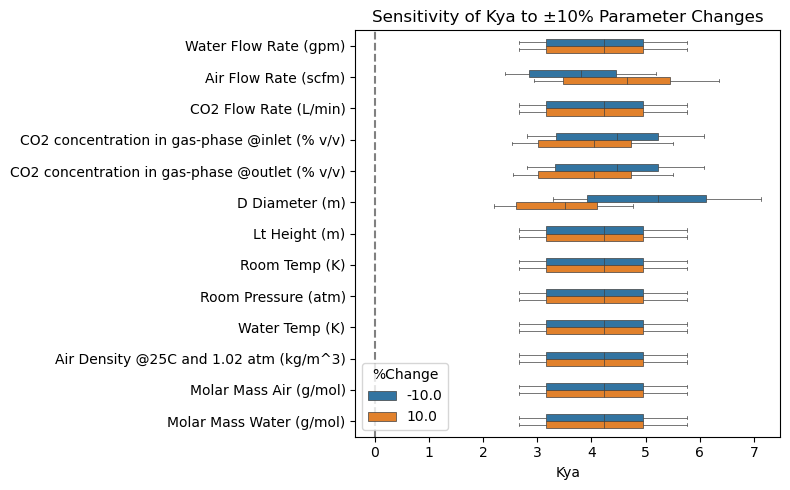

In [695]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))  # increase height for more space
sns.boxplot(
    data=df_sens,
    y='Parameter',
    x='Kya',
    hue='%Change',
    dodge=True,
    width=0.45,        # narrower boxes = more space between hues
    linewidth=.5,      # make hue groups more distinct
    palette=sns.color_palette("tab10")
)
plt.axvline(0, color='gray', linestyle='--')
plt.title('Sensitivity of Kya to ±10% Parameter Changes')
plt.xlabel('Kya')
plt.ylabel('')
plt.tight_layout()
plt.show()



In [510]:
'''
# Updated master_calc with all parameters
# Definitions for variable names (keys)
y_in = 'CO2 mole fraction in gas-phase @inlet'
y_out = 'CO2 mole fraction in gas-phase @outlet'
x_in = 'CO2 mole fraction in Liquid-phase @inlet'
x_out = 'CO2 mole fraction in Liquid-phase @outlet'
y_star = 'CO2 mole fraction in gas-phase @Equilibrium'
y_in_pct = 'CO2 concentration in gas-phase @inlet (% v/v)'
y_out_pct = 'CO2 concentration in gas-phase @outlet (% v/v)'
'''

"\n# Updated master_calc with all parameters\n# Definitions for variable names (keys)\ny_in = 'CO2 mole fraction in gas-phase @inlet'\ny_out = 'CO2 mole fraction in gas-phase @outlet'\nx_in = 'CO2 mole fraction in Liquid-phase @inlet'\nx_out = 'CO2 mole fraction in Liquid-phase @outlet'\ny_star = 'CO2 mole fraction in gas-phase @Equilibrium'\ny_in_pct = 'CO2 concentration in gas-phase @inlet (% v/v)'\ny_out_pct = 'CO2 concentration in gas-phase @outlet (% v/v)'\n"